In [1]:
# import the usual suspects
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from src.cf_generator_dice import DiceCFGenerator
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score,balanced_accuracy_score

In [2]:
from seaborn import cm

In [3]:
import importlib
import src.utils as utl
importlib.reload(utl)

<module 'src.utils' from '/home/vbonsignori/L2loRe/src/utils.py'>

In [4]:
import src.fancy_plots as fplt
importlib.reload(fplt)


<module 'src.fancy_plots' from '/home/vbonsignori/L2loRe/src/fancy_plots.py'>

In [5]:
# let's find the different files we need
config = utl.load_config('config.yaml')
cf_results = config['paths']['counterfactuals']


dt_name = "toy_dataset"
dt_name = "german_credit"

dt_name = 'breast_cancer'
dt_name = "adult48k"
cf_method = ["dice","ils",'lore','growingspheres'][-4]



name_dataset = {"german_credit": "German Credit",
                "toy_dataset":"Toy Dataset",
                "adult48k":"Adult",
                "breast_cancer": "Breast Cancer",
                }[dt_name]
cf_results

'counterfactuals/'

In [6]:
data_processor = DataProcessor(config=config)
splits = data_processor.load_splits(dt_name)

Loaded feature names from data/processed/adult48k/feature_names.csv
Loaded X_train from data/processed/adult48k/X_train.npz
Loaded y_train from data/processed/adult48k/y_train.npz
Loaded X_test from data/processed/adult48k/X_test.npz
Loaded y_test from data/processed/adult48k/y_test.npz
Loaded X_calibration from data/processed/adult48k/X_calibration.npz
Loaded y_calibration from data/processed/adult48k/y_calibration.npz


In [7]:

model_trainer = ModelTrainer(config)
models = model_trainer.train_model(X_train=splits['X_train'], 
                                    y_train=splits['y_train'], 
                                    X_test=splits['X_test'], 
                                    y_test=splits['y_test'],
                                    dataset_name=dt_name)
print(models.keys())

Processing lip_mlp for adult48k
Loaded lip_mlp model from models/adult48k/lip_mlp.pkl
Loaded existing lip_mlp model
Processing random_forest for adult48k
Loaded random_forest model from models/adult48k/random_forest.pkl
Loaded existing random_forest model
Processing mlp for adult48k
Loaded mlp model from models/adult48k/mlp.pkl
Loaded existing mlp model
Processing xgboost for adult48k
Loaded xgboost model from models/adult48k/xgboost.pkl
Loaded existing xgboost model
Processing lgbm for adult48k
Loaded lgbm model from models/adult48k/lgbm.pkl
Loaded existing lgbm model
dict_keys(['lip_mlp', 'random_forest', 'mlp', 'xgboost', 'lgbm'])


In [8]:
for k in models.keys():
    roc = roc_auc_score(splits['y_test'], models[k].predict_proba(splits['X_test'])[:,1]).round(2)
    print(f"Model {k} ROC AUC: {roc}")
    acc = accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Accuracy: {acc}")
    f1_ = f1_score(splits['y_test'], models[k].predict(splits['X_test']), average='weighted').round(2)
    print(f"Model {k} F1 Score: {f1_}")
    balanced_accuracy = balanced_accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Balanced Accuracy: {balanced_accuracy}")
    #print(classification_report(splits['y_test'], models[k].predict(splits['X_test'])))
    utl.plot_confusion_ascii(splits['y_test'], models[k].predict(splits['X_test']),ascii_set=5)
    # print(confusion_matrix(splits['y_test'], models[k].predict(splits['X_test']))
    print()
    

Model lip_mlp ROC AUC: 0.92
Model lip_mlp Accuracy: 0.85
Model lip_mlp F1 Score: 0.85
Model lip_mlp Balanced Accuracy: 0.75
◈•
∙◑

Model random_forest ROC AUC: 0.91
Model random_forest Accuracy: 0.87
Model random_forest F1 Score: 0.86
Model random_forest Balanced Accuracy: 0.78
◈∙
∙◈

Model mlp ROC AUC: 0.91
Model mlp Accuracy: 0.86
Model mlp F1 Score: 0.86
Model mlp Balanced Accuracy: 0.77
◈∙
∙◈

Model xgboost ROC AUC: 0.92
Model xgboost Accuracy: 0.87
Model xgboost F1 Score: 0.87
Model xgboost Balanced Accuracy: 0.8
■∙
 ◈

Model lgbm ROC AUC: 0.92
Model lgbm Accuracy: 0.87
Model lgbm F1 Score: 0.87
Model lgbm Balanced Accuracy: 0.8
■•
 ◑



In [9]:
# import the fancy for bar chart tdqm
from  tqdm.notebook import tqdm,tnrange, tqdm_notebook
import time




In [10]:
np.random.randint(0,7), np.random.rand()*7

(5, 2.4269404561804624)

In [11]:

                 
import pickle

#with open("debug/ranking_new_t.pkl", "rb") as f:
#    all_ranking_list_mean, all_ranking_list_std, all_ranking_list_min, all_ranking_list_max, all_probabs,corrects = pickle.load(f)


### The distances took into account

In [12]:
from src.distances import get_distances
metrics = ["l0", "l1", "l2", "inf", "-inf", "sqeuclidean", "mae", "cosine", "correlation", "chebyshev", "minkowski", "canberra", "braycurtis", "hamming", "jaccard", "wasserstein", "spearman", "kendall", "centered_l2", "centered_cosine"]

In [13]:
'''
X = splits['X_test'].values[:10]

x = splits['X_test'].values[0]

print("Distance examples:")
for metric in metrics:
        distances = get_distances(X,x, policy=metric)
        #print(f"{metric} : {[f'{d:.2f}' for d in distances]}")
        plt.plot(distances, label=metric)
plt.legend()
plt.show()
'''

'\nX = splits[\'X_test\'].values[:10]\n\nx = splits[\'X_test\'].values[0]\n\nprint("Distance examples:")\nfor metric in metrics:\n        distances = get_distances(X,x, policy=metric)\n        #print(f"{metric} : {[f\'{d:.2f}\' for d in distances]}")\n        plt.plot(distances, label=metric)\nplt.legend()\nplt.show()\n'

In [14]:
all_stats = {
    model_name: {
        'distances': {
            metric: {
                'min': [],   # One value per sample
                'max': [],   # One value per sample
                'mean': [],  # One value per sample, equal to min or max if only one value
                'std': [],   # One value per sample
            } for metric in metrics
        },
        'probabs': [],      # Keep the original probabs
        'corrects': [],      # Keep original # corrects
        'mean_conf': []  # One value per sample
        
    } for model_name in models.keys()
}




In [15]:
all_stats_test = {
    model_name: {
        'distances': {
            metric: {
                'min': [],   # One value per sample
                'max': [],   # One value per sample
                'mean': [],  # One value per sample, equal to min or max if only one value
                'std': [],   # One value per sample
            } for metric in metrics
        },
        'probabs': [],      # Keep the original probabs
        'corrects': [],      # Keep original # corrects
        'mean_conf': []  # One value per sample
        
    } for model_name in models.keys()
}


## Scaled features?

In [16]:
scaled = False


In [17]:
fname = os.path.join(cf_method,dt_name+f"_ranking{'_scaled' if scaled else ''}.pkl")
if utl.check_file_exists(fname):
    with open(fname, "rb") as f:
        all_stats = pickle.load(f)
        print("Loaded",fname)
else:
    print("!"*6,fname, "not found")
fname_test = os.path.join(cf_method,dt_name+f"_ranking_test{'_scaled' if scaled else ''}.pkl")
if utl.check_file_exists(fname_test):
    with open(fname_test,'rb') as f:
        all_stats_test = pickle.load(f)
        print("Loaded",fname_test)
else:
    print("!"*6,fname_test, "not found")


Loaded dice/adult48k_ranking.pkl
Loaded dice/adult48k_ranking_test.pkl


In [18]:
'''# plot the boxplot of the features
plt.figure(figsize=(12, 6))
sns.boxplot(data=np.vstack([splits["X_train"], splits["X_calibration"], splits["X_test"]]), orient="h")

plt.xlabel('Value')
plt.title('Boxplot of Features')
plt.show()
'''

'# plot the boxplot of the features\nplt.figure(figsize=(12, 6))\nsns.boxplot(data=np.vstack([splits["X_train"], splits["X_calibration"], splits["X_test"]]), orient="h")\n\nplt.xlabel(\'Value\')\nplt.title(\'Boxplot of Features\')\nplt.show()\n'

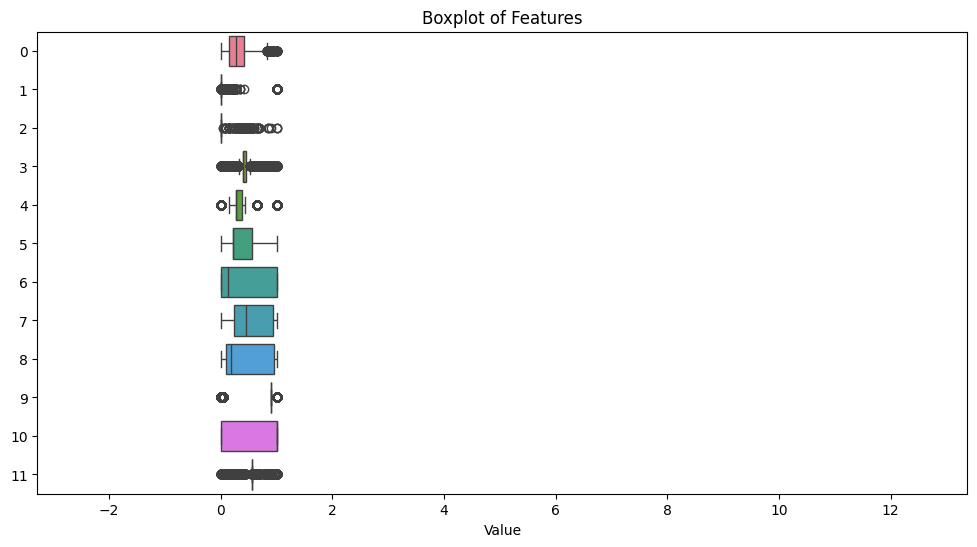

In [19]:

# Stack all splits as numpy arrays
X_all = np.vstack([
    splits["X_train"].values,
    splits["X_calibration"].values,
])
plot_lim = X_all.min(axis=0).min(), X_all.max(axis=0).max()
plot_lim = (plot_lim[0] - 0.1, plot_lim[1] + 0.1)
curr_min = X_all.min(0)
curr_max = X_all.max(0)

def normalize(x):
    # normalize the features of the dataframe or numpy array to [0,1]
    return (x - curr_min) / (curr_max - curr_min)

plt.figure(figsize=(12, 6))
sns.boxplot(data=normalize(X_all), orient="h")
plt.xlabel('Value')
plt.xlim(plot_lim)
plt.title('Boxplot of Features')
plt.show()


In [20]:
def check_res(stats_dict = all_stats,k="mlp"):
    """this function return True if the distances related to the model k are already computed"""
    # try if the list containing the mean dists has length > 0
    try:
        print("("+str(len(stats_dict[k]['distances']['l2']['mean'])),"elements computed)")
        return len(stats_dict[k]['distances']['l2']['mean']) >= 100
    except Exception as e:
        print(e)
        return False
for k in models.keys():
    print(k, "computed?",check_res(stats_dict = all_stats,k=k))
    
    print("\t","test?",check_res(stats_dict=all_stats_test,k=k))

'lip_mlp'
lip_mlp computed? False
'lip_mlp'
	 test? False
(300 elements computed)
random_forest computed? True
(500 elements computed)
	 test? True
(300 elements computed)
mlp computed? True
(500 elements computed)
	 test? True
(300 elements computed)
xgboost computed? True
(500 elements computed)
	 test? True
(300 elements computed)
lgbm computed? True
(500 elements computed)
	 test? True


In [28]:
compute_test = False

In [29]:
all_stats_tmp = all_stats_test if compute_test else all_stats
def select_test (x):return "test" in x if compute_test else ("test" not in x)

In [30]:
select_test("test"), select_test("train")

(False, True)

In [31]:
# do a fast check to see if the 
for k in models.keys():
    result_f = os.path.join("counterfactuals",k,dt_name)
    print(result_f)
    try:
        list_files = os.listdir(result_f)
        print("Number of files",len(list_files))
    except:
        print(result_f,"File not found")

counterfactuals/lip_mlp/adult48k
Number of files 10
counterfactuals/random_forest/adult48k
Number of files 10
counterfactuals/mlp/adult48k
Number of files 12
counterfactuals/xgboost/adult48k
Number of files 8
counterfactuals/lgbm/adult48k
Number of files 8


## Compute the distances 
Counterfactual should be already present

In [32]:
cfs["cfs"][i]["counterfactuals"].std(axis=0)

age               0.054267
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
workclass         0.000000
education         0.121065
marital-status    0.000000
occupation        0.057253
relationship      0.000000
race              0.061648
sex               0.000000
native-country    0.004502
target            0.000000
dtype: float64

In [33]:
"growing_spheres",cf_method

('growing_spheres', 'dice')

In [34]:
start = time.time()
for jj,k in enumerate(tqdm(models.keys())):
    not_found = 0
    # load the counterfactuals
    result_folder_path = os.path.join(cf_results,
                        k,
                        dt_name)
    print("looking into the folder ",result_folder_path)
    results = os.listdir(result_folder_path)
    # remove the ones that are not npz
    results = [r for r in results if r.endswith(".npz") and cf_method in r]
    # remove those that contains "test" in the name
    results = [r for r in results if select_test(r)]
    # take the most recent using os.path.getmtime
    results = sorted(results,key=lambda x: os.path.getmtime(os.path.join(result_folder_path,x)),reverse=True)
    print("I found",len(results),"files")
    if len(results) > 1:
        for i,f in enumerate(results):
            print(str(i)+")",f)
        # i = input()
        # take the most recent 
        i = 0
        if isinstance(i,int):
            results = [results[i]]
        else:
            results = [results[-1]]
    print("for model",k,"using file",results[-1])

    r = results[-1]
    
    print("checking",r)
    # load the counterfactuals most recent using nupy
    cfs = np.load(os.path.join(result_folder_path, r),allow_pickle=True)#results[0]), allow_pickle=True)
    # cfs is a dictionary with keys "cfs" as the only key (it's an npz file). The value of "cfs" is a np array of dictionaries. The keys of the dictionaries are:, instace_idx (the index of the instance in the calibration set), original_instance (the original class of the instance), true_class (the true class of the instance)
    print(cfs["cfs"].shape[0])
    if check_res(stats_dict=all_stats_tmp,k=k):
        print("Already computed for model",k,end=" elements:")
        print(len(all_stats_tmp[k]['distances']['l2']['mean']))
        continue
    else:
        print("Not computed for model",k,"computing...")
        # reset the stats for the model
        all_stats_tmp[k] = {
            'distances': {metric: {'min': [],'max': [],'mean': [],'std': [], } for metric in metrics},
            'probabs': [],'corrects': [],'mean_conf': []
        }

    probabs, corrects, confs = [], [], []
    
    for i in tnrange(cfs["cfs"].shape[0]):
        ## let's see the output for the original instance
        ## and check if the model is predicting the class (even to check what true_class is)
        ## then we can check the counterfactuals and see if the model is predicting the opposite class
        ## and if it aligns with the "target" attribute of the counterfactuals
        original_instance = cfs["cfs"][i]["original_instance"]
        # original instance is not anymore the right one sadly... 
        # therefore we get the original instance from the dataset itself by using the "compute_test" flag and the  instance_idx attribute
        original_instance = splits[('X_test' if  compute_test else 'X_calibration')].iloc[cfs["cfs"][i]["instance_idx"]].values.reshape(1,-1)
        original_class = cfs["cfs"][i]["true_class"].values
        
        #true_cf = cfs["cfs"][i]["counterfactuals"].target.values
        pred = models[k].predict(original_instance)
        pred_prob = models[k].predict_proba(original_instance)[0]
        correct = original_class == pred
        #print(pred,original_class)
        if cf_method != "ils":
            good_cfs = cfs["cfs"][i]["counterfactuals"].values[:,:-1]

            pred_cfs = cfs["cfs"][i]["counterfactuals"].values[:,-1]
            if len (good_cfs) > 0:
                mean_confidences_cfs = models[k].predict_proba(good_cfs).mean(axis=0)
            else:
                mean_confidences_cfs = np.array([np.nan,np.nan])
        else:
            good_cfs = cfs["cfs"][i]["counterfactuals"].values[:,:-1]
            if len (good_cfs) > 0:
                pred_good_cfs = models[k].predict_proba(good_cfs)
                pred_cfs = pred_good_cfs.argmax(axis=1)
                mean_confidences_cfs = pred_good_cfs.mean(axis=0)
            else:
                pred_good_cfs

                mean_confidences_cfs = np.array([np.nan,np.nan])
        #    
        #good_cfs = good_cfs[true_cf != pred]
        true_cf = np.ones(len(good_cfs))#true_cf[true_cf != pred]

        if normalize:
            if len(good_cfs) > 0:
                good_cfs = normalize(good_cfs)
                original_instance = normalize(original_instance)
        for metric in metrics:
            if len(good_cfs) == 0:
                distancies = np.array([np.inf])
                print("NOT FOUND COUNTERFACTUALS FOR SAMPLE",i)
                not_found+=1
            else:
                if (abs(pred-pred_cfs).mean() != 1).all():
                    print("The counterfactuals should have class != "+str(pred_cfs[:10]
                                 )+" are not aligned with the target"+str(pred.mean()))
                    distancies = np.array([np.inf])
                else:
                    distancies = get_distances(good_cfs, 
                                           original_instance,
                                        policy=metric)
                    
            
            all_stats_tmp[k]['distances'][metric]['min'].append(distancies.min(axis=0))
            all_stats_tmp[k]['distances'][metric]['max'].append(distancies.max(axis=0))
            all_stats_tmp[k]['distances'][metric]['mean'].append(distancies.mean(axis=0))
            all_stats_tmp[k]['distances'][metric]['std'].append(distancies.std(axis=0))
            
        probabs.append(pred_prob)
        corrects.append(correct)
        confs.append(mean_confidences_cfs)
        # print(distancies)
        #if i / 4 < 1:
        #   sns.kdeplot(distancies,cumulative=False,label=str(i)+" "+str(len(distancies))+ " counterfactuals "+k,ax=axs[i])
    all_stats_tmp[k]['probabs'] = probabs
    all_stats_tmp[k]['corrects'] = corrects
    all_stats_tmp[k]['mean_conf'] = confs
    print("For the model ",k,"not found",not_found,"counterfactuals")


  0%|          | 0/5 [00:00<?, ?it/s]

looking into the folder  counterfactuals/lip_mlp/adult48k
I found 1 files
for model lip_mlp using file cf_results_dice_kdtree_calibration_20260301_152933.npz
checking cf_results_dice_kdtree_calibration_20260301_152933.npz
300
'lip_mlp'
Not computed for model lip_mlp computing...


  0%|          | 0/300 [00:00<?, ?it/s]

For the model  lip_mlp not found 0 counterfactuals
looking into the folder  counterfactuals/random_forest/adult48k
I found 1 files
for model random_forest using file cf_results_dice_kdtree_calibration_20250309_202807.npz
checking cf_results_dice_kdtree_calibration_20250309_202807.npz
300
(300 elements computed)
Already computed for model random_forest elements:300
looking into the folder  counterfactuals/mlp/adult48k
I found 1 files
for model mlp using file cf_results_dice_kdtree_calibration_20250305_073155.npz
checking cf_results_dice_kdtree_calibration_20250305_073155.npz
300
(300 elements computed)
Already computed for model mlp elements:300
looking into the folder  counterfactuals/xgboost/adult48k
I found 1 files
for model xgboost using file cf_results_dice_kdtree_calibration_20250313_065644.npz
checking cf_results_dice_kdtree_calibration_20250313_065644.npz
300
(300 elements computed)
Already computed for model xgboost elements:300
looking into the folder  counterfactuals/lgbm/adu

In [35]:
'''from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm
import os
import numpy as np

def process_model(k):
    not_found = 0
    result_folder_path = os.path.join(cf_results, k, dt_name)
    results = os.listdir(result_folder_path)
    results = [r for r in results if r.endswith(".npz") and cf_method in r]
    results = [r for r in results if select_test(r)]
    results = sorted(results, key=lambda x: os.path.getmtime(os.path.join(result_folder_path, x)), reverse=True)

    if len(results) > 1:
        results = [results[0]]

    r = results[-1]
    cfs = np.load(os.path.join(result_folder_path, r), allow_pickle=True)

    if check_res(stats_dict=all_stats_tmp, k=k):
        return f"Already computed for model {k}"

    probabs, corrects, confs = [], [], []

    for i in range(cfs["cfs"].shape[0]):
        original_instance = splits[('X_test' if compute_test else 'X_calibration')].iloc[cfs["cfs"][i]["instance_idx"]].values.reshape(1, -1)
        original_class = cfs["cfs"][i]["true_class"].values
        pred = models[k].predict(original_instance)
        pred_prob = models[k].predict_proba(original_instance)[0]
        correct = original_class == pred
        good_cfs = cfs["cfs"][i]["counterfactuals"].values[:, :-1]
        pred_cfs = cfs["cfs"][i]["counterfactuals"].values[:, -1]

        if len(good_cfs) > 0:
            mean_confidences_cfs = models[k].predict_proba(good_cfs).mean(axis=0)
        else:
            mean_confidences_cfs = np.array([np.nan, np.nan])

        for metric in metrics:
            if len(good_cfs) == 0:
                distancies = np.array([np.inf])
                not_found += 1
            else:
                distancies = get_distances(good_cfs, cfs["cfs"][i]["original_instance"].values, policy=metric)

            all_stats_tmp[k]['distances'][metric]['min'].append(distancies.min(axis=0))
            all_stats_tmp[k]['distances'][metric]['max'].append(distancies.max(axis=0))
            all_stats_tmp[k]['distances'][metric]['mean'].append(distancies.mean(axis=0))
            all_stats_tmp[k]['distances'][metric]['std'].append(distancies.std(axis=0))

        probabs.append(pred_prob)
        corrects.append(correct)
        confs.append(mean_confidences_cfs)

    all_stats_tmp[k]['probabs'] = probabs
    all_stats_tmp[k]['corrects'] = corrects
    all_stats_tmp[k]['mean_conf'] = confs

    return f"For the model {k}, not found {not_found} counterfactuals"

# Parallelize the loop using ThreadPoolExecutor
with ThreadPoolExecutor() as executor:
    results = list(tqdm(executor.map(process_model, models.keys()), total=len(models.keys())))

# Print results
for res in results:
    print(res)'''

'from concurrent.futures import ThreadPoolExecutor\nfrom tqdm.notebook import tqdm\nimport os\nimport numpy as np\n\ndef process_model(k):\n    not_found = 0\n    result_folder_path = os.path.join(cf_results, k, dt_name)\n    results = os.listdir(result_folder_path)\n    results = [r for r in results if r.endswith(".npz") and cf_method in r]\n    results = [r for r in results if select_test(r)]\n    results = sorted(results, key=lambda x: os.path.getmtime(os.path.join(result_folder_path, x)), reverse=True)\n\n    if len(results) > 1:\n        results = [results[0]]\n\n    r = results[-1]\n    cfs = np.load(os.path.join(result_folder_path, r), allow_pickle=True)\n\n    if check_res(stats_dict=all_stats_tmp, k=k):\n        return f"Already computed for model {k}"\n\n    probabs, corrects, confs = [], [], []\n\n    for i in range(cfs["cfs"].shape[0]):\n        original_instance = splits[(\'X_test\' if compute_test else \'X_calibration\')].iloc[cfs["cfs"][i]["instance_idx"]].values.reshape

In [36]:
print("Ready?")

Ready?


In [37]:
fname,fname_test

('dice/adult48k_ranking.pkl', 'dice/adult48k_ranking_test.pkl')

## Save files for the distances
if not already present

In [38]:
if compute_test:
    all_stats_test = all_stats_tmp
else:
    all_stats = all_stats_tmp
compute_test

False

In [39]:
max(all_stats_tmp[k]['distances']['l2']['max']),min(all_stats_tmp[k]['distances']['l2']['min'])

(12.775171751825518, 0.02202989801047857)

Checking cosine distances for lip_mlp max min value 0.019491697699596466 max value 0.7270703098803846
Checking cosine distances for lip_mlp min min value 1.918674500067663e-05 max value 0.46861706766167965
Checking cosine distances for lip_mlp mean min value 0.006133113857813646 max value 0.6159891806015159
0.8533333333333334
0.854
True True
Checking cosine distances for random_forest max min value 0.0031180546028847234 max value 0.6322943273261082
Checking cosine distances for random_forest min min value 0.00023194002531223834 max value 0.24013910773601932
Checking cosine distances for random_forest mean min value 0.001922148252737746 max value 0.4244649427113024
0.8633333333333333
0.866
True True
Checking cosine distances for mlp max min value 0.0027001954061768307 max value 0.6211142394948418
Checking cosine distances for mlp min min value 0.0002789454824351223 max value 0.23983507504802837
Checking cosine distances for mlp mean min value 0.001724634384106527 max value 0.37885427264

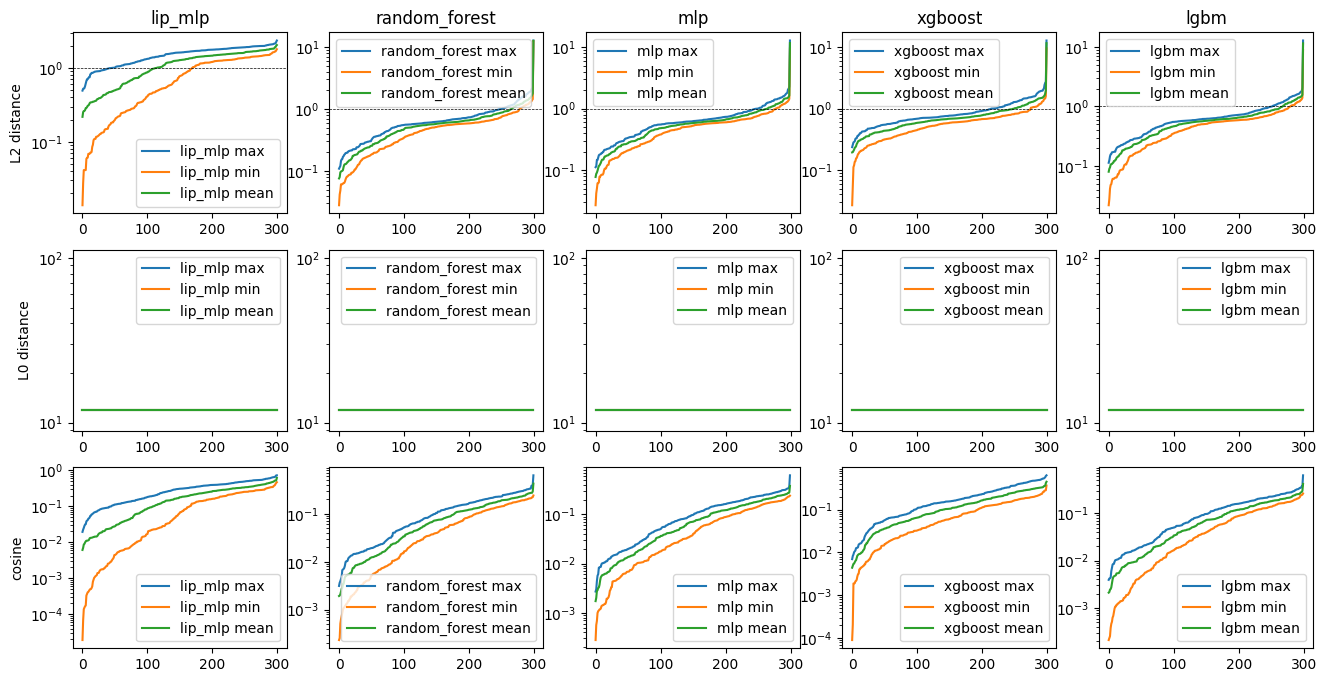

In [40]:
# to check plot the distances of the l2 metric for all the models
# use four subplots
num_models = len(models)
fig, axs = plt.subplots(3,num_models,figsize=(16,8))
axs = axs.flatten()
for jj,k in enumerate(models.keys()):
    axs[jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['l2']['max']) ),label=k+" max")
    axs[jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['l2']['min']) ),label=k+" min")
    axs[jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['l2']['mean']) ),label=k+" mean")
    # check the correct list
    axs[jj].axhline(1, color='black', linestyle='--', linewidth=0.5)
    axs[num_models+jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['l0']['max']) ),label=k+" max")
    axs[num_models+jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['l0']['min']) ),label=k+" min")
    axs[num_models+jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['l0']['mean'])),label=k+" mean")

    axs[2*num_models+jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['cosine']['max'])),label=k+" max")
    axs[2*num_models+jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['cosine']['min'])),label=k+" min")
    axs[2*num_models+jj].plot(sorted(np.array(all_stats_tmp[k]['distances']['cosine']['mean'])),label=k+" mean")

    if jj== 0:
        axs[jj].set_ylabel("L2 distance")
        axs[num_models+jj].set_ylabel("L0 distance")
        axs[2*num_models+jj].set_ylabel("cosine")
    if jj>= num_models*3-num_models:
        axs[jj].set_xlabel("Sample index")
        
    # assert that the cosine ones are in 0-2
    for mode in ['max','min','mean']:
        # assert len(all_stats[k]['distances']['cosine'][mode])>0, "No cosine distances found for model "+k
        
        minv = np.array(all_stats[k]['distances']['cosine'][mode]).min()
        maxv = np.array(all_stats[k]['distances']['cosine'][mode]).max()
        print("Checking cosine distances for",k,mode,"min value",minv,"max value",maxv)
        #assert ((np.array(all_stats[k]['distances']['cosine'][mode]) >= 0) & (np.array(all_stats[k]['distances']['cosine'][mode]) <= 2)).all()

    print(np.array(all_stats[k]['corrects']).sum()/len(all_stats[k]['corrects']))
    print(np.array(all_stats_test[k]['corrects']).sum()/len(all_stats_test[k]['corrects']))
    print(0.0==0,1.0==1)

    # set the legend and the title
    axs[jj].legend()
    axs[jj].set_title(k)

for ax in axs:
    ax.legend()
    #set yscale log
    ax.set_yscale("log")
    
plt.show()
    
    

In [41]:
# If I did an error, I have to remove the the whole list of distances for the models in the all_stats dictionary
# I will "re initialize" the list of distances for the models
'''
for k in ["mlp","lgbm","xgboost"]:
    all_stats[k]['distances'] = {
            metric: {
                'min': [],   # One value per sample
                'max': [],   # One value per samplea
                'mean': [],  # One value per sample, equal to min or max if only one value
                'std': [],   # One value per sample
            } for metric in metrics
        }
'''

'\nfor k in ["mlp","lgbm","xgboost"]:\n    all_stats[k][\'distances\'] = {\n            metric: {\n                \'min\': [],   # One value per sample\n                \'max\': [],   # One value per samplea\n                \'mean\': [],  # One value per sample, equal to min or max if only one value\n                \'std\': [],   # One value per sample\n            } for metric in metrics\n        }\n'

In [42]:
# check how many distancies are computed, i fear that I have confused the test and calibration set
for k in models.keys():
    print(k, "computed?",check_res(stats_dict = all_stats,k=k))
    print("\t","test?",check_res(stats_dict=all_stats_test,k=k))

(300 elements computed)
lip_mlp computed? True
(500 elements computed)
	 test? True
(300 elements computed)
random_forest computed? True
(500 elements computed)
	 test? True
(300 elements computed)
mlp computed? True
(500 elements computed)
	 test? True
(300 elements computed)
xgboost computed? True
(500 elements computed)
	 test? True
(300 elements computed)
lgbm computed? True
(500 elements computed)
	 test? True


In [43]:
fname

'dice/adult48k_ranking.pkl'

In [44]:
with open(fname, "wb") as f:
    pickle.dump(all_stats, f)
    print("dumped",fname)
#if not utl.check_file_exists(fname):
#else:
#    print("File already exists, updating",fname)
    

dumped dice/adult48k_ranking.pkl


In [45]:
fname_test

'dice/adult48k_ranking_test.pkl'

In [46]:
with open(fname_test, "wb") as f:
    pickle.dump(all_stats_test, f)
    print("dumped",fname_test)
# if not utl.check_file_exists(fname_test):
# else:
#     print("File already exists",fname_test)


dumped dice/adult48k_ranking_test.pkl


## End of File